# Vehicle-Tier Trust Score Analyzer — **v2** (enriched · multi-percentage · paper-aligned)

A clean re-build of the vehicle-tier Trust Analyzer that fixes the v1 mismatches and produces a
**richer trust score for the full-mode LLM detector**, while keeping every thesis equation
(Eqs 3.3–3.5, 3.22–3.28) intact.

### What changed vs. v1
| v1 issue | v2 fix |
|---|---|
| Trained on the small `evaluation_runs/` v10–v40 sample (mismatch #4) | Trains on a real **attacker-percentage sweep**: `pct20` + `pct40` + `pct100` (true legitimate class) |
| Exported weights were the stale **8-feature** model | **26-feature** enriched vector; weights + φ_trust re-exported |
| No per-vehicle **score** exported (only weights) | Exports `vehicle_trust_scores_v2.csv` keyed to the pipeline contract |
| Only raw `rssi_dbm` | **RSSI verification** (`verification_state`, `mismatch_m`) — MISMATCH ≈ 98.6% sybil |
| No persistence signal | **Identity lifetime** (legit 6.5 s vs sybil 3.0 s) + beacon count |
| Trust used only local, correlated signals | **Cross-tier consensus** (RSU/controller) → independent reputation for `T_hist` |
| 5/6-class only, count-keyed | **7-class** `{0..6}`, windows keyed in **seconds** per the data contract |

The analytic `T_RSSI/T_behav/T_hist` keep their paper equations; the enrichment feeds (a) the MLP
feature vector that produces **φ_trust** (the deployed trust score the LLM reads) and (b) `T_hist`'s
reputation prior. No equation is rewritten.

> All heavy logic lives in the validated `ml/trust_v2/trust_v2_lib.py`; this notebook is a documented
> interactive driver over it.

## 0. Setup — import the validated library

In [17]:
import sys, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# trust_v2_lib.py lives in the analyzer dir (notebooks/ -> ..); the pre-reorg
# ../ml/trust_v2 path no longer exists. Locate the library robustly.
LIB_DIR = next(p for p in (Path.cwd().parent, Path.cwd().parent / "ml" / "trust_v2")
               if (p / "trust_v2_lib.py").exists())
sys.path.insert(0, str(LIB_DIR))
import trust_v2_lib as T
print("datasets:")
for d in T.DATASETS:
    print("  ", d, "exists" if Path(d).exists() else "MISSING")
print(f"\n{len(T.FEATURE_COLS)} features:\n ", T.FEATURE_COLS)
print("\n7-class taxonomy:", T.CLASS_NAMES)

datasets:
   /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/datasets/seq6_pct_sweep_20260708_101653/pct100_s1 exists
   /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/datasets/seq6_pct_sweep_20260709_023108/pct20_s1 exists
   /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/datasets/seq6_pct_sweep_20260709_023108/pct40_s1 exists

26 features:
  ['T_RSSI', 'T_behav', 'T_hist', 'T_composite', 'token_valid', 'raw_rate_deviation', 'raw_coloc_mean', 'n_beacons_norm', 'had_coloc_observation', 'range_anomaly', 'rssi_distance_mismatch', 'rssi_colocation', 'trajectory_shadowing', 'traj_shadow_score', 'traj_shadow_compared', 'iat_entropy', 'rssi_mismatch_frac', 'mismatch_m_mean', 'identity_lifetime', 'beacon_count_mean', 'rsu_observer_count', 'rsu_report_count', 'rsu_verified_prob', 'rsu_false_decision', 'ctrl_trust', 'ctrl_observer_count']

7-class taxonomy: {0: 'legitimate', 1:

## 1. Build (or load) the enriched windows

`build_pipeline` loads each run **one at a time** (memory-safe over the ~14 GB of logs), joins the
enriched RSSI-verification + RSU/controller consensus, labels 7-class, and aggregates to W=10-beacon
windows with the paper's trust components. Results are **cached to parquet** — the first run is slow
(reads the logs), every re-run is instant.

- `subsample_frac` keeps whole observer vehicles (whole FL clients). `0.05` = smoke, **`0.15–0.3`** for a real model.
- Delete `cache/windows.parquet` to force a rebuild at a different `frac`.

In [2]:
CACHE = LIB_DIR / "cache" / "windows_shared.parquet"   # rebuilt under the shared identity subsample
# Identity subsample is now the SHARED one (identity_manifest.KEEP_FRAC); this arg is ignored.
SUBSAMPLE_FRAC = 1.0

In [ ]:
# CACHE.unlink(missing_ok=True)   # uncomment ONLY to force a full ~2.3 hr rebuild of the windows.
# The cache is valid; the earlier failure was the split key-mismatch (fixed in trust_v2_lib),
# not the windows — so keep loading the cache instead of rebuilding.

In [4]:
print(T.__file__)

/home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/trust_v2/trust_v2_lib.py


In [5]:
with open(T.__file__) as f:
    lines = f.readlines()
print("".join(lines[248:266]))

        neighbor["rssi_mismatch_flag"] = neighbor["rssi_mismatch_flag"].fillna(0).astype("int8")
        del rssi
    else:
        neighbor["rssi_dbm"] = np.float32(np.nan)
        neighbor["mismatch_m"] = np.float32(np.nan)
        neighbor["rssi_mismatch_flag"] = np.int8(0)

    # ── cross-tier consensus join (tiny logs; as-of per claimed_id) ─────────
    for tier, cdf in load_consensus(dataset_dir):
        cdf = cdf.dropna(subset=["time", "observed_claimed_id"]).sort_values("time")
        cdf["observed_claimed_id"] = cdf["observed_claimed_id"].astype("int64")
        # consensus logs are sparse/aggregated — carry the last known report forward
        # per claimed id (a claimed id's RSU/controller reputation persists).
        neighbor = pd.merge_asof(
            neighbor.sort_values("time"), cdf, on="time",
            by="observed_claimed_id", direction="backward", tolerance=30.0)

    vmap = load_vehicle_to_rsu(dataset_dir)



In [7]:
print(T.__file__)

/home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/trust_v2/trust_v2_lib.py


In [8]:
with open(T.__file__) as f:
    lines = f.readlines()
print("".join(lines[245:267]))

            neighbor, rssi[keep_rssi], on="time",
            by=["observer_vehicle_id", "observed_claimed_id"],
            direction="nearest", tolerance=0.5)
        neighbor["rssi_mismatch_flag"] = neighbor["rssi_mismatch_flag"].fillna(0).astype("int8")
        del rssi
    else:
        neighbor["rssi_dbm"] = np.float32(np.nan)
        neighbor["mismatch_m"] = np.float32(np.nan)
        neighbor["rssi_mismatch_flag"] = np.int8(0)

    # ── cross-tier consensus join (tiny logs; as-of per claimed_id) ─────────
    for tier, cdf in load_consensus(dataset_dir):
        cdf = cdf.dropna(subset=["time", "observed_claimed_id"]).sort_values("time")
        cdf["observed_claimed_id"] = cdf["observed_claimed_id"].astype("int64")
        # consensus logs are sparse/aggregated — carry the last known report forward
        # per claimed id (a claimed id's RSU/controller reputation persists).
        neighbor = pd.merge_asof(
            neighbor.sort_values("time"), cdf, on="time",
           

In [ ]:
path = T.__file__

with open(path) as f:
    content = f.read()

old = '''    for tier, cdf in load_consensus(dataset_dir):
        cdf = cdf.dropna(subset=["time", "observed_claimed_id"]).sort_values("time")
        cdf["observed_claimed_id"] = cdf["observed_claimed_id"].astype("int64")
        # consensus logs are sparse/aggregated — carry the last known report forward
        # per claimed id (a claimed id's RSU/controller reputation persists).
        neighbor = pd.merge_asof(
            neighbor.sort_values("time"), cdf, on="time",
            by="observed_claimed_id", direction="backward", tolerance=30.0)'''

new = '''    for tier, cdf in load_consensus(dataset_dir):
        cdf = cdf.dropna(subset=["time", "observed_claimed_id"]).sort_values("time").copy()
        cdf["observed_claimed_id"] = cdf["observed_claimed_id"].astype("int64")
        cdf["time"] = cdf["time"].astype("float64")
        neighbor["time"] = neighbor["time"].astype("float64")
        neighbor["observed_claimed_id"] = neighbor["observed_claimed_id"].astype("int64")
        # consensus logs are sparse/aggregated — carry the last known report forward
        # per claimed id (a claimed id's RSU/controller reputation persists).
        neighbor = pd.merge_asof(
            neighbor.sort_values("time"), cdf, on="time",
            by="observed_claimed_id", direction="backward", tolerance=30.0)'''

# Idempotent: only patch if the unpatched block is still present, so
# "Restart & Run All" does not raise on an already-patched file.
if old in content:
    content = content.replace(old, new)
    with open(path, "w") as f:
        f.write(content)
    print("consensus block patched")
else:
    print("consensus block already patched — skipping")

In [10]:
path = T.__file__
with open(path) as f:
    content = f.read()

old_rssi = '''        keep_rssi = ["time", "observer_vehicle_id", "observed_claimed_id",
                     "rssi_dbm", "mismatch_m", "rssi_mismatch_flag"]
        neighbor = neighbor.sort_values("time")
        rssi = rssi.sort_values("time")
        neighbor = pd.merge_asof('''

new_rssi = '''        keep_rssi = ["time", "observer_vehicle_id", "observed_claimed_id",
                     "rssi_dbm", "mismatch_m", "rssi_mismatch_flag"]
        rssi["time"] = rssi["time"].astype("float64")
        neighbor["time"] = neighbor["time"].astype("float64")
        neighbor = neighbor.sort_values("time")
        rssi = rssi.sort_values("time")
        neighbor = pd.merge_asof('''

if old_rssi in content:
    content = content.replace(old_rssi, new_rssi)
    with open(path, "w") as f:
        f.write(content)
    print("rssi block patched")
else:
    print("rssi pattern not found — may already differ, check manually")

rssi block patched


In [5]:
t0 = time.time()
windows = T.build_pipeline(subsample_frac=SUBSAMPLE_FRAC, cache=str(CACHE))
print(f"\n{len(windows):,} windows in {time.time()-t0:.0f}s")
print("label (is_sybil):", windows["label"].value_counts().to_dict())
print("attack_type {0..6}:", dict(sorted(windows["attack_type"].value_counts().items())))
print("by attacker %:", windows.groupby('attack_percentage')['label'].agg(['size','mean']).round(3).to_dict())
windows.head(3)


    [safe-read] vehicle_neighbor_table_log.csv: scanned 53,702,132 rows, kept 27,330,183 (50.9%)
    [safe-read] rssi_verification_log.csv: scanned 53,839,340 rows, kept 27,391,335 (50.9%)
  pct100_s1: 2,743,149 windows | pos_rate=0.113
    [safe-read] vehicle_neighbor_table_log.csv: scanned 62,496,678 rows, kept 25,973,501 (41.6%)
    [safe-read] rssi_verification_log.csv: scanned 62,677,278 rows, kept 26,044,070 (41.6%)
  pct20_s1: 2,601,782 windows | pos_rate=0.079
    [safe-read] vehicle_neighbor_table_log.csv: scanned 60,646,098 rows, kept 22,910,667 (37.8%)
    [safe-read] rssi_verification_log.csv: scanned 60,795,090 rows, kept 22,962,976 (37.8%)
  pct40_s1: 2,298,383 windows | pos_rate=0.103
  cached windows -> /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/trust_v2/cache/windows_shared.parquet

7,643,314 windows in 8223s
label (is_sybil): {0: 6888313, 1: 755001}
attack_type {0..6}: {0: 6888313, 1: 228471, 2: 385598, 3: 82185, 4: 49722

,run_id,observer_vehicle_id,observed_claimed_id,observed_real_id,window_start,window_end,n_beacons,n_beacons_norm,beacon_rate,rssi_mean,...,raw_coloc_max,coloc_flag,had_coloc_observation,raw_rate_deviation,T_behav,T_RSSI,T_hist,T_composite,active_attack_pct,group_key
0,pct100_s1_type0,0,8,8,60.610100,60.710499,10,1.0,89.642312,-81.648178,...,0.977756,1,1,7.964231,0.000348,0.674081,0.428881,0.398401,40,pct100_s1_type0__vid8
1,pct100_s1_type0,0,8,8,60.710499,60.800900,10,1.0,99.556756,-80.799744,...,0.977756,1,1,8.955676,0.000129,0.353955,0.276778,0.224654,40,pct100_s1_type0__vid8
2,pct100_s1_type0,0,8,8,60.800900,61.019001,10,1.0,41.265190,-79.662338,...,0.960378,1,1,3.126519,0.043870,0.616181,0.315367,0.354243,40,pct100_s1_type0__vid8


## 2. EDA — do the enriched signals separate the classes?

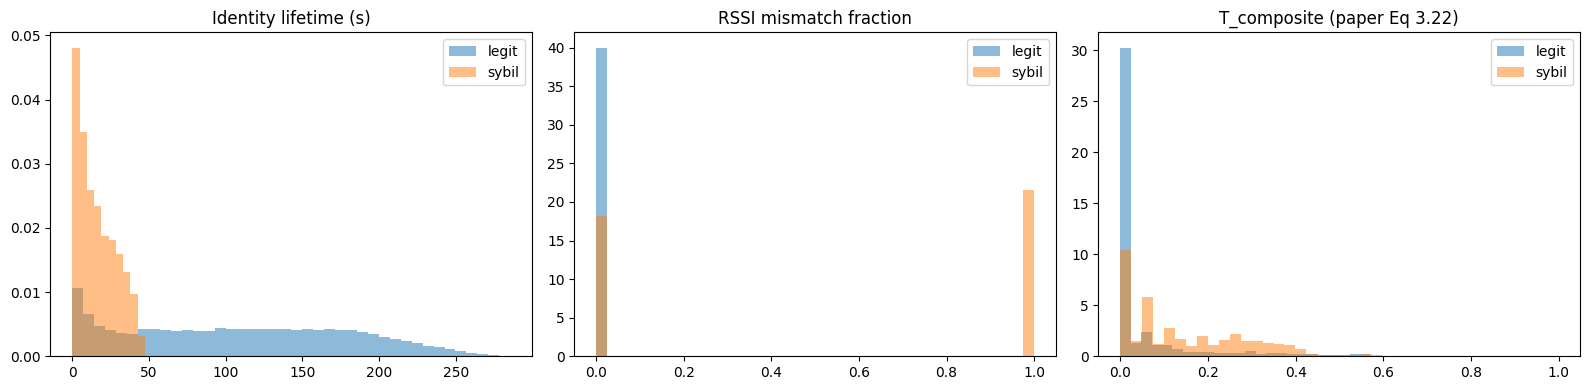

Per-attack-type positive rate (7-class):
                size  mean
attack_type               
0            6888313   0.0
1             228471   1.0
2             385598   1.0
3              82185   1.0
4              49722   1.0
5               8982   1.0
6                 43   1.0


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, col, title in zip(ax,
        ["identity_lifetime", "rssi_mismatch_frac", "T_composite"],
        ["Identity lifetime (s)", "RSSI mismatch fraction", "T_composite (paper Eq 3.22)"]):
    for lab, name in [(0, "legit"), (1, "sybil")]:
        a.hist(windows.loc[windows.label == lab, col].dropna(), bins=40, alpha=0.5,
               density=True, label=name)
    a.set_title(title); a.legend()
plt.tight_layout(); plt.show()

print("Per-attack-type positive rate (7-class):")
print(windows.groupby("attack_type")["label"].agg(["size", "mean"]).round(3))

## 3. Split, impute, standardize

Group-stratified 70/15/15 by `(run_id, ground-truth vehicle)` within each `(attacker%, attack_type)`
stratum — no vehicle leaks across train/val/test. Train-only median-impute + standardization; the
stats are exported so C++/inference standardizes identically.

In [19]:
import importlib
importlib.reload(T)                      # pick up the fixed group_stratified_split from disk
windows = pd.read_parquet(str(CACHE))    # RAW windows from cache (instant) — avoids double-standardization
print("reloaded:", windows.shape, "run_ids:", windows['run_id'].nunique())

reloaded: (7643314, 45) run_ids: 21


In [20]:
windows = T.group_stratified_split(windows)
windows, STATS = T.prep_features(windows)
print("split:", windows["split"].value_counts().to_dict())
tr, va, te = [windows[windows.split == s] for s in ("train", "val", "test")]
NF = len(T.FEATURE_COLS)
print(f"features={NF}  train={len(tr):,} val={len(va):,} test={len(te):,}")

split: {'train': 5649945, 'test': 1110521, 'val': 882848}
features=26  train=5,649,945 val=882,848 test=1,110,521


## 4. Train — centralized warm-start → hierarchical FL

The MLP is `Linear(26,32)→ReLU→Drop→Linear(32,16)→ReLU→Linear(16,1)`; the **16-dim penultimate
activation is φ_trust** — the deployed trust score. Training: a short centralized warm-start, then
hierarchical FedProx FL (per-OBU clients → RSU size-weighted avg → SDN trimmed-mean, + DP noise,
Eqs 3.26–3.28), class-weighted and stratified-sampled, early-stopped on val-MCC.

In [21]:
pos_rate = tr["label"].mean()
POS_WEIGHT = float(np.clip((1 - pos_rate) / max(pos_rate, 1e-6), 1.0, 20.0))
HP = dict(dropout=0.1, fedprox_mu=0.001, dp_sigma=0.02, local_lr=0.05,
          batch_size=32, local_epochs=2, trim_k=1)

warm = T.centralized_pretrain(tr, T.FEATURE_COLS, NF, epochs=3, pos_weight=POS_WEIGHT)
wm, _, _ = T.evaluate_state(warm, va, T.FEATURE_COLS, NF)
print(f"warm-start val MCC = {wm['mcc']:.4f}")

state, history, best = T.train_fl(tr, va, T.FEATURE_COLS, HP, NF, max_rounds=40,
                                  pos_weight=POS_WEIGHT, warm_start=warm)
print(f"\nbest val MCC = {best:.4f}")

warm-start val MCC = 0.9873
  round   1  val_mcc=0.9875  best=0.9875
  round   5  val_mcc=0.9860  best=0.9875
  round   7  val_mcc=0.9857  best=0.9875

best val MCC = 0.9875


### FL convergence

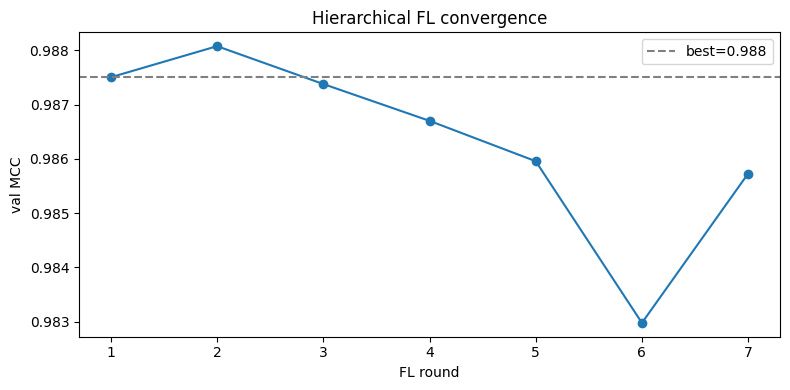

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(history["round"], history["val_mcc"], marker="o")
plt.axhline(best, ls="--", c="grey", label=f"best={best:.3f}")
plt.xlabel("FL round"); plt.ylabel("val MCC"); plt.title("Hierarchical FL convergence"); plt.legend()
plt.tight_layout(); plt.show()

## 5. Test-set evaluation

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
tm, probs, phi = T.evaluate_state(state, te, T.FEATURE_COLS, NF)
print("TEST:", {k: round(v, 4) for k, v in tm.items()})
pred = (probs >= 0.5).astype(int)
print("\n", classification_report(te["label"], pred, target_names=["legit", "sybil"], zero_division=0))
print("confusion:\n", confusion_matrix(te["label"], pred))

TEST: {'mcc': 0.9858, 'f1': 0.9873, 'precision': 0.9943, 'recall': 0.9804, 'accuracy': 0.9973}

               precision    recall  f1-score   support

       legit       1.00      1.00      1.00    992772
       sybil       0.99      0.98      0.99    117749

    accuracy                           1.00   1110521
   macro avg       1.00      0.99      0.99   1110521
weighted avg       1.00      1.00      1.00   1110521

confusion:
 [[992113    659]
 [  2313 115436]]


## 5b. Intensity-robustness — **evaluation only** (honest use of `active_attack_pct`)

`active_attack_pct` (the 20→100 ladder) is **NOT a model feature** — a real vehicle cannot observe the
attack density, so feeding it would be oracle leakage. It is kept purely as **metadata** to *stratify the
evaluation*: how does detection hold up as attack intensity rises? The model stays blind to it.

MCC by intensity ladder (active_attack_pct):
 active_attack_pct
20     0.988
40     0.984
60     0.989
80     0.983
100    0.984
Name: test_mcc, dtype: float64

MCC by run attacker % (attack_percentage):
 attack_percentage
20     0.987
40     0.978
100    0.989
Name: test_mcc, dtype: float64


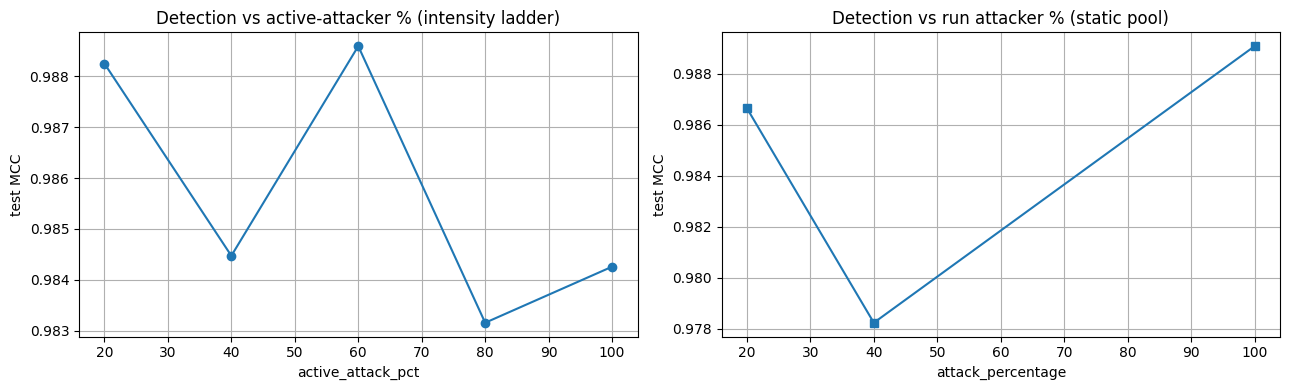

In [24]:
te_eval = te.copy(); te_eval["pred"] = pred
from sklearn.metrics import matthews_corrcoef
def _mcc(g):
    return matthews_corrcoef(g["label"], g["pred"]) if g["label"].nunique() > 1 else np.nan
by_intensity = te_eval.groupby("active_attack_pct").apply(_mcc).rename("test_mcc")
by_static    = te_eval.groupby("attack_percentage").apply(_mcc).rename("test_mcc")
print("MCC by intensity ladder (active_attack_pct):\n", by_intensity.round(3))
print("\nMCC by run attacker % (attack_percentage):\n", by_static.round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
by_intensity.plot(marker="o", ax=ax[0], title="Detection vs active-attacker % (intensity ladder)")
by_static.plot(marker="s", ax=ax[1], title="Detection vs run attacker % (static pool)")
for a in ax: a.set_ylabel("test MCC"); a.grid(True)
plt.tight_layout(); plt.show()

## 6. Export for the full-mode LLM detector

- `vehicle_trust_scores_v2.csv` — one row per window, keyed **`(claimed_node_id, window_start_seconds, split)`**,
  with `attack_type∈{0..6}`, `is_sybil`, the `T_*` components, **`phi_trust_0..15`**, and the interpretable
  enriched fields (`rssi_mismatch_frac`, `identity_lifetime`, `rsu_report_count`, `ctrl_trust`, …) that give
  the LLM type-bearing evidence to reason over.
- `vehicle_trust_mlp_v2.json` — weights + standardization stats + hyperparameters.

In [25]:
OUT = LIB_DIR / "outputs"
scores = T.export_scores(windows, state, T.FEATURE_COLS, OUT / "vehicle_trust_scores_v2.csv")
T.export_weights_json(state, T.FEATURE_COLS, STATS, {**T.DEFAULT_HP, **HP}, OUT / "vehicle_trust_mlp_v2.json")
# Fusion contract twin (grid-snapped, join-keyed) -> notebooks/outputs/
fusion = T.export_fusion_parquet(windows, state, T.FEATURE_COLS)
print(f"exported {len(scores):,} scored windows -> {OUT}")
print(f"fusion parquet: {fusion.shape} -> {T.ARTIFACTS_DIR}/trust_vehicle_tier.parquet")
print("columns:", list(scores.columns)[:14], "... +phi_trust_0..15")
scores[["claimed_node_id","window_start_seconds","split","attack_type","is_sybil",
        "phi_trust_score","T_composite","identity_lifetime","rssi_mismatch_frac"]].head()


exported 7,643,314 scored windows -> /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/trust_v2/outputs
fusion parquet: (50140, 34) -> /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/notebooks/outputs/trust_vehicle_tier.parquet
columns: ['claimed_node_id', 'window_start_seconds', 'window_end_seconds', 'split', 'run_id', 'attack_percentage', 'active_attack_pct', 'attack_type', 'is_sybil', 'phi_trust_score', 'T_RSSI', 'T_behav', 'T_hist', 'T_composite'] ... +phi_trust_0..15


,claimed_node_id,window_start_seconds,split,attack_type,is_sybil,phi_trust_score,T_composite,identity_lifetime,rssi_mismatch_frac
0,8,60.610100,test,0,0,0.216979,2.903059,-1.387264,-0.228643
1,8,60.710499,test,0,0,0.164301,1.401408,-1.386028,-0.228643
2,8,60.800900,test,0,0,0.159670,2.521415,-1.383048,-0.228643
3,8,61.019001,test,0,0,0.147575,1.393887,-1.381757,-0.228643
4,8,61.113499,test,0,0,0.147379,2.065816,-1.379101,-0.228643


## 7. Ablation — which enrichment matters?

Retrains (centralized, fast) with each enriched block dropped, to show the trust score genuinely
leans on the new signals (RSSI-verification / persistence / consensus), not just the v1 features.

In [26]:
BLOCKS = {
    "full": [],
    "-rssi_verify": ["rssi_mismatch_frac", "mismatch_m_mean"],
    "-persistence": ["identity_lifetime", "beacon_count_mean"],
    "-consensus":   ["rsu_observer_count","rsu_report_count","rsu_verified_prob",
                     "rsu_false_decision","ctrl_trust","ctrl_observer_count"],
}
rows = []
for name, drop in BLOCKS.items():
    cols = [c for c in T.FEATURE_COLS if c not in drop]
    st = T.centralized_pretrain(tr, cols, len(cols), epochs=4, pos_weight=POS_WEIGHT)
    m, _, _ = T.evaluate_state(st, te, cols, len(cols))
    rows.append({"config": name, "n_feat": len(cols), "test_mcc": round(m["mcc"], 4),
                 "test_f1": round(m["f1"], 4)})
pd.DataFrame(rows)

,config,n_feat,test_mcc,test_f1
0,full,26,0.9865,0.9879
1,-rssi_verify,24,0.9860,0.9875
2,-persistence,24,0.9846,0.9862
3,-consensus,20,0.9858,0.9873


## 8. Hyperparameter sensitivity analysis (report Table 4.3)

The report (§4.3.3) resolves the Trust Analyzer's open hyperparameters through a **grid-search
sensitivity analysis on the validation partition**, using **MCC** as the objective (§3.4.15) and a
**one-factor-at-a-time (OFAT)** procedure: *"for each parameter, a candidate set of values is
evaluated while holding the others constant, and the value yielding the highest validation MCC is
selected."* The sweep must also *"characterise the trade-off between detection accuracy, OBU
resource cost, and gradient-privacy strength."* Table 4.3 lists eight axes:

| Axis | Candidate values | Kind |
|---|---|---|
| Hidden widths (L1, L2) | (16, 8), (32, 16), (64, 32) | architecture / OBU cost |
| Dropout rate | 0.1, 0.2, 0.3, 0.5 | regularisation |
| Local learning rate | 0.001, 0.005, 0.01, 0.05 | optimisation |
| Batch size | 16, 32, 64 | optimisation |
| Local epochs / round | 1, 3, 5 | FL |
| FedProx µ | 0.001, 0.01, 0.1 | FL |
| DP noise σ_dp | 0.05, 0.1, 0.2 | gradient privacy |
| Sliding window W | 5, 10, 20 beacons | feature construction |

**Method here.** Group-aware **5-fold CV** over the train+val identities (the test split is never
touched), MCC objective, per-fold train-only standardisation (no leakage). Selection is on the
**mean CV validation MCC**. Seven axes reuse the cached W = 10 windows; the **W** axis needs the
windows rebuilt at each W and is gated behind a flag (§8.3).

**Tuning economy (declared, following the Temporal Analyzer's precedent of a ~1 M-window val
subsample + reduced client ratio).** Each CV fold caps the training pool to `TUNE_MAX_WINDOWS`
whole FL clients, uses a reduced FL-round budget and client-participation ratio, and a short
centralized warm-start. These bound tuning cost; the *deployed* model in §4 is retrained at full
budget on the full data with the selected values. Set the knobs below to `None`/larger for a
full-fidelity (multi-hour → run in tmux) sweep.

In [ ]:
# ── 8.1  CV harness + tuning economies ──────────────────────────────────────
from sklearn.metrics import matthews_corrcoef  # noqa (used indirectly via T)

CV_FOLDS         = 5           # report specifies stratified 5-fold CV
CV_ROUNDS        = 12          # FL rounds/fold during tuning (final model uses 40, §4)
CV_PATIENCE      = 4
TUNE_SEL_FRAC    = 0.20        # client participation during tuning (deployed run uses 0.30)
TUNE_MAX_WINDOWS = 1_000_000   # cap train windows/fold (whole clients); None = full fidelity
SEED             = T.RNG_SEED

# OFAT anchor: every value is a legitimate Table-4.3 candidate, so "hold others
# constant" never sits off-grid. The sweep re-selects each axis around this anchor.
BASE = dict(hidden1=32, hidden2=16, dropout=0.1, local_lr=0.05, batch_size=32,
            local_epochs=3, fedprox_mu=0.001, dp_sigma=0.1, trim_k=1)

def _cap_clients(df, max_rows, seed):
    """Keep whole FL clients (run_id, observer) up to ~max_rows windows."""
    if not max_rows or len(df) <= max_rows:
        return df
    cid = df["run_id"].astype(str) + "#" + df["observer_vehicle_id"].astype(str)
    sizes = cid.value_counts()
    r = np.random.default_rng(seed)
    ids = r.permutation(sizes.index.to_numpy())
    keep, tot = [], 0
    for c in ids:
        keep.append(c); tot += int(sizes[c])
        if tot >= max_rows:
            break
    return df[cid.isin(set(keep))]

def precompute_folds(pool, k, max_windows, seed=SEED):
    """Group k-fold by real-vehicle group_key; per fold: cap train clients, then
    train-only impute+standardize (leakage-free). Architecture-independent, so it is
    built ONCE and reused across every hyperparameter configuration."""
    groups = pd.Series(pool["group_key"].dropna().unique())
    r = np.random.default_rng(seed)
    groups = groups.sample(frac=1.0, random_state=seed).to_numpy()
    fold_groups = np.array_split(groups, k)
    folds = []
    for i in range(k):
        held = set(fold_groups[i])
        in_val = pool["group_key"].isin(held)
        tr_raw = _cap_clients(pool[~in_val], max_windows, seed + i)
        va_raw = pool[in_val]
        d = pd.concat([tr_raw.assign(split="train"), va_raw.assign(split="val")], ignore_index=True)
        d, _ = T.prep_features(d)                      # fits on split=='train' only
        ftr, fva = d[d.split == "train"], d[d.split == "val"]
        pr = ftr["label"].mean()
        pw = float(np.clip((1 - pr) / max(pr, 1e-6), 1.0, 20.0))
        folds.append((ftr, fva, pw))
        print(f"  fold {i}: train={len(ftr):,} ({tr_raw['run_id'].nunique()} runs) "
              f"val={len(fva):,}  pos_rate={pr:.3f}  pw={pw:.2f}")
    return folds

def cv_mcc(hp, folds, rounds=CV_ROUNDS, patience=CV_PATIENCE, sel_frac=TUNE_SEL_FRAC):
    """Mean±std validation MCC over the precomputed folds for one hp config."""
    mccs = []
    for ftr, fva, pw in folds:
        warm = T.centralized_pretrain(ftr, T.FEATURE_COLS, NF, epochs=2, pos_weight=pw,
                                      hidden1=hp.get("hidden1", 32), hidden2=hp.get("hidden2", 16),
                                      dropout=hp.get("dropout", 0.1))
        _, _, best = T.train_fl(ftr, fva, T.FEATURE_COLS, hp, NF, max_rounds=rounds,
                                patience=patience, pos_weight=pw, warm_start=warm,
                                sel_frac=sel_frac, min_clients=8, verbose=False)
        mccs.append(best)
    return float(np.mean(mccs)), float(np.std(mccs))

def n_params(h1, h2, nf=None):
    nf = nf or NF
    return nf * h1 + h1 + h1 * h2 + h2 + h2 * 1 + 1   # fc1 + fc2 + fc3 (weights+biases)

# raw (un-standardized) windows -> train+val pool (test identities held out)
raw = T.group_stratified_split(pd.read_parquet(str(CACHE)))
POOL = raw[raw.split.isin(["train", "val"])].copy()
print(f"CV pool: {len(POOL):,} windows | "
      f"{POOL.groupby(['run_id','observer_vehicle_id']).ngroups} clients | "
      f"pos_rate={POOL['label'].mean():.3f}")
FOLDS = precompute_folds(POOL, CV_FOLDS, TUNE_MAX_WINDOWS)


In [ ]:
# ── 8.2  OFAT sweep over the 7 non-window axes (cached W=10 windows) ─────────
TABLE_4_3 = {
    "hidden":       [(16, 8), (32, 16), (64, 32)],
    "dropout":      [0.1, 0.2, 0.3, 0.5],
    "local_lr":     [0.001, 0.005, 0.01, 0.05],
    "batch_size":   [16, 32, 64],
    "local_epochs": [1, 3, 5],
    "fedprox_mu":   [0.001, 0.01, 0.1],
    "dp_sigma":     [0.05, 0.1, 0.2],
    # "W" is swept separately in §8.3 (needs a window rebuild)
}

t0 = time.time()
records = []
for axis, cands in TABLE_4_3.items():
    for v in cands:
        hp = dict(BASE)
        if axis == "hidden":
            hp["hidden1"], hp["hidden2"] = v
            base_val = (BASE["hidden1"], BASE["hidden2"]); label = f"{v[0]}/{v[1]}"
        else:
            hp[axis] = v; base_val = BASE[axis]; label = v
        m, s = cv_mcc(hp, FOLDS)
        records.append({"axis": axis, "value": label, "cv_mcc": m, "cv_std": s,
                        "n_params": n_params(hp["hidden1"], hp["hidden2"]),
                        "dp_sigma": hp["dp_sigma"], "is_anchor": (v == base_val)})
        print(f"  {axis:13s} = {str(label):8s}  cv_mcc={m:.4f} ± {s:.4f}   "
              f"[{time.time()-t0:.0f}s]")

sens_df = pd.DataFrame(records)
OUT = LIB_DIR / "outputs"
sens_df.to_csv(OUT / "trust_sensitivity_table_4_3.csv", index=False)
print(f"\nwrote {OUT/'trust_sensitivity_table_4_3.csv'}  ({time.time()-t0:.0f}s total)")
display(sens_df)


In [ ]:
# ── plot: validation MCC vs each swept axis (baseline ✕, selected ●) ─────────
axes_order = ["hidden", "dropout", "local_lr", "batch_size",
              "local_epochs", "fedprox_mu", "dp_sigma"]
fig, axs = plt.subplots(2, 4, figsize=(17, 7.5)); axs = axs.ravel()
for k, axis in enumerate(axes_order):
    d = sens_df[sens_df.axis == axis].reset_index(drop=True)
    x = np.arange(len(d))
    axs[k].errorbar(x, d.cv_mcc, yerr=d.cv_std, marker="o", capsize=3, color="#1f77b4")
    best = d.cv_mcc.idxmax()
    axs[k].scatter([best], [d.cv_mcc[best]], s=140, color="#2ca02c", zorder=5, label="selected")
    anc = d.index[d.is_anchor]
    if len(anc):
        axs[k].scatter(anc, d.cv_mcc[anc], marker="x", s=90, color="#d62728", zorder=6, label="anchor")
    axs[k].set_xticks(x); axs[k].set_xticklabels([str(v) for v in d.value], rotation=30, ha="right")
    axs[k].set_title(axis); axs[k].set_ylabel("CV val MCC"); axs[k].grid(alpha=0.3)
    axs[k].legend(fontsize=8)
axs[-1].axis("off")
fig.suptitle("Trust Analyzer — Table 4.3 sensitivity (5-fold CV, MCC objective)", y=1.02)
plt.tight_layout(); plt.show()


### 8.3  Sliding-window W ∈ {5, 10, 20} (needs a window rebuild)

W changes how beacons are aggregated into windows, so unlike the other axes it cannot reuse the
cached table — the enriched windows must be rebuilt from the raw logs at each W (streams ~14 GB of
neighbour + RSSI logs per run). This is gated behind `RUN_W_SWEEP`; each W is cached to its own
parquet, so a rerun is instant. Run it in **tmux** the first time.

In [ ]:
# ── 8.3  W sweep (gated) ─────────────────────────────────────────────────────
RUN_W_SWEEP = False   # set True to rebuild windows at W=5 and W=20 (slow first run; tmux)

W_CACHE = {5:  LIB_DIR / "cache" / "windows_shared_W5.parquet",
           10: CACHE,                                            # existing W=10 cache
           20: LIB_DIR / "cache" / "windows_shared_W20.parquet"}

w_records = []
if RUN_W_SWEEP:
    tw = time.time()
    for W in (5, 10, 20):
        raw_w = T.build_pipeline(window_w=W, cache=str(W_CACHE[W]))   # builds or loads
        raw_w = T.group_stratified_split(raw_w)
        pool_w = raw_w[raw_w.split.isin(["train", "val"])].copy()
        folds_w = precompute_folds(pool_w, CV_FOLDS, TUNE_MAX_WINDOWS)
        m, s = cv_mcc(BASE, folds_w)
        w_records.append({"axis": "W", "value": W, "cv_mcc": m, "cv_std": s,
                          "n_params": n_params(BASE["hidden1"], BASE["hidden2"]),
                          "dp_sigma": BASE["dp_sigma"], "is_anchor": (W == 10)})
        print(f"  W = {W:2d}  cv_mcc={m:.4f} ± {s:.4f}   [{time.time()-tw:.0f}s]")
    w_df = pd.DataFrame(w_records)
    w_df.to_csv(LIB_DIR / "outputs" / "trust_sensitivity_W.csv", index=False)
    display(w_df)
else:
    print("W sweep skipped (RUN_W_SWEEP=False). Set True to rebuild windows at W=5/20.")


In [ ]:
# ── 8.4  Selected configuration = argmax mean CV-MCC per axis ────────────────
all_sens = pd.concat([sens_df] + ([w_df] if w_records else []), ignore_index=True)
selected = (all_sens.sort_values("cv_mcc", ascending=False)
                    .groupby("axis", as_index=False).first()
                    .rename(columns={"value": "selected", "cv_mcc": "best_cv_mcc"}))

# accuracy vs OBU-cost vs privacy read-out the report asks for
span = (all_sens.groupby("axis")
                .agg(min_mcc=("cv_mcc", "min"), max_mcc=("cv_mcc", "max"))
                .assign(mcc_span=lambda d: d.max_mcc - d.min_mcc))
selected = selected.merge(span["mcc_span"], on="axis")
selected = selected.sort_values("mcc_span", ascending=False).reset_index(drop=True)
print("Selected values (argmax mean CV MCC), axes ranked by influence (MCC span):")
display(selected[["axis", "selected", "best_cv_mcc", "mcc_span", "n_params"]])

# assemble the selected hp dict for the deployed retrain (§4)
sel = {r.axis: r.selected for r in selected.itertuples()}
SELECTED_HP = dict(trim_k=1)
if "hidden" in sel:
    h = str(sel["hidden"]).split("/"); SELECTED_HP["hidden1"], SELECTED_HP["hidden2"] = int(h[0]), int(h[1])
for a in ("dropout", "local_lr", "batch_size", "local_epochs", "fedprox_mu", "dp_sigma"):
    if a in sel:
        SELECTED_HP[a] = (int(sel[a]) if a in ("batch_size", "local_epochs") else float(sel[a]))
SELECTED_W = int(sel.get("W", 10))
print("\nSELECTED_HP =", SELECTED_HP, "| W =", SELECTED_W)
print("Feed these into the §4 training cell (HP/warm-start) for the deployed model.")


**Reading the sweep.** Rank the axes by their CV-MCC span (§8.4): the largest-span axes are the
levers the analyzer is genuinely sensitive to; small-span axes can be fixed on cost/privacy grounds
with little accuracy penalty. Two trade-offs the report (§4.3.3) explicitly asks the sweep to
characterise fall straight out of the table:

* **OBU resource cost** — the `n_params` column: (16, 8) → (64, 32) grows the φ_trust head; keep the
  smallest width whose CV MCC is within noise of the best.
* **Gradient privacy** — `dp_sigma` 0.05 → 0.2 raises DP noise; if its span is small the analyzer
  can afford stronger privacy (larger σ) essentially for free.

The selected values here tune *the sweep's reduced budget*; the deployed model (§4) is retrained at
full budget on the full data with `SELECTED_HP`, and only then is the held-out test split scored.

## 9. Summary

**v2 delivers**, on the pct20+pct40+pct100 sweep: a 7-class-aligned, seconds-keyed vehicle-tier trust
analyzer whose enriched **φ_trust** and interpretable `T_*` + signature fields feed the full-mode LLM.
Every thesis equation is preserved; the enrichment is in the observable inputs and the exported
evidence, not the math.

**Feeds the fusion** via `vehicle_trust_scores_v2.csv` → join into `ml/fullmode/build_evidence.py`
(key: `claimed_node_id`, `window_start_seconds`).

**Retrain manually:** `PYTHONUNBUFFERED=1 ml/.venv/bin/python ml/trust_v2/trust_v2_lib.py --train --frac 0.15 --rounds 40`
(auto-uses the cache after the first build).